# AQI Predictor — Exploratory Data Analysis

Covers Bahawalpur, Lahore, and Islamabad: per-city AQI trends, pollutant
correlations, and hourly patterns, plus a cross-city comparison at the end.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CITIES = ["bahawalpur", "lahore", "islamabad"]

def load_city_data(city):
    df = pd.read_csv(f"../data/{city}/raw_aqi_data.csv", parse_dates=["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)
    return df

data = {city: load_city_data(city) for city in CITIES}

for city, df in data.items():
    print(f"{city.title()}: {df.shape[0]} rows, {df.shape[1]} columns")


Bahawalpur: 42913 rows, 11 columns
Lahore: 42816 rows, 11 columns
Islamabad: 42816 rows, 11 columns


## Bahawalpur

In [2]:
df = data["bahawalpur"]
df.head()

,datetime,aqi_epa,openweather_aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2021-08-21 16:00:00,166.0,5,574.11,0.09,2.57,130.18,3.76,85.23,147.10,5.57
1,2021-08-21 17:00:00,168.0,5,560.76,0.09,3.00,135.90,4.23,87.98,151.69,5.32
2,2021-08-21 18:00:00,165.0,5,554.09,0.06,5.44,124.45,3.64,82.64,149.87,6.78
3,2021-08-21 19:00:00,160.0,5,580.79,0.00,7.28,108.72,2.59,73.51,129.74,9.12
4,2021-08-21 20:00:00,154.0,5,627.52,0.00,7.54,103.00,1.89,61.60,95.70,10.89


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42913 entries, 0 to 42912
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         42913 non-null  datetime64[ns]
 1   aqi_epa          42886 non-null  float64       
 2   openweather_aqi  42913 non-null  int64         
 3   co               42913 non-null  float64       
 4   no               42913 non-null  float64       
 5   no2              42913 non-null  float64       
 6   o3               42913 non-null  float64       
 7   so2              42913 non-null  float64       
 8   pm2_5            42913 non-null  float64       
 9   pm10             42913 non-null  float64       
 10  nh3              42913 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 3.6 MB


,datetime,aqi_epa,openweather_aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,42913,42886.000000,42913.000000,42913.000000,42913.000000,42913.000000,42913.000000,42913.000000,42913.000000,42913.000000,42913.000000
mean,2024-02-17 04:22:13.777643264,149.933731,4.152005,799.644437,1.369395,13.025037,73.059518,3.874098,82.479869,149.780806,16.284037
min,2021-08-21 16:00:00,0.000000,1.000000,81.130000,0.000000,-9999.000000,-9999.000000,0.090000,0.000000,-9999.000000,0.000000
25%,2022-11-15 16:00:00,93.000000,4.000000,285.950000,0.000000,1.650000,41.130000,1.420000,31.800000,72.350000,4.190000
50%,2024-02-15 16:00:00,148.000000,4.000000,560.760000,0.060000,5.270000,69.790000,2.740000,54.410000,120.200000,8.870000
75%,2025-05-21 16:00:00,178.000000,5.000000,1094.010000,0.370000,19.360000,104.110000,4.830000,105.400000,193.010000,20.010000
max,2026-08-24 15:00:00,500.000000,6.000000,5981.450000,99.240000,208.380000,394.820000,82.020000,626.140000,1817.690000,303.980000
std,NaN,76.760561,0.958224,708.638205,4.955907,70.770707,65.930736,4.069765,76.430380,130.463438,21.059161


In [4]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate timestamps:", df["datetime"].duplicated().sum())

Missing values:
datetime            0
aqi_epa            27
openweather_aqi     0
co                  0
no                  0
no2                 0
o3                  0
so2                 0
pm2_5               0
pm10                0
nh3                 0
dtype: int64

Duplicate timestamps: 0


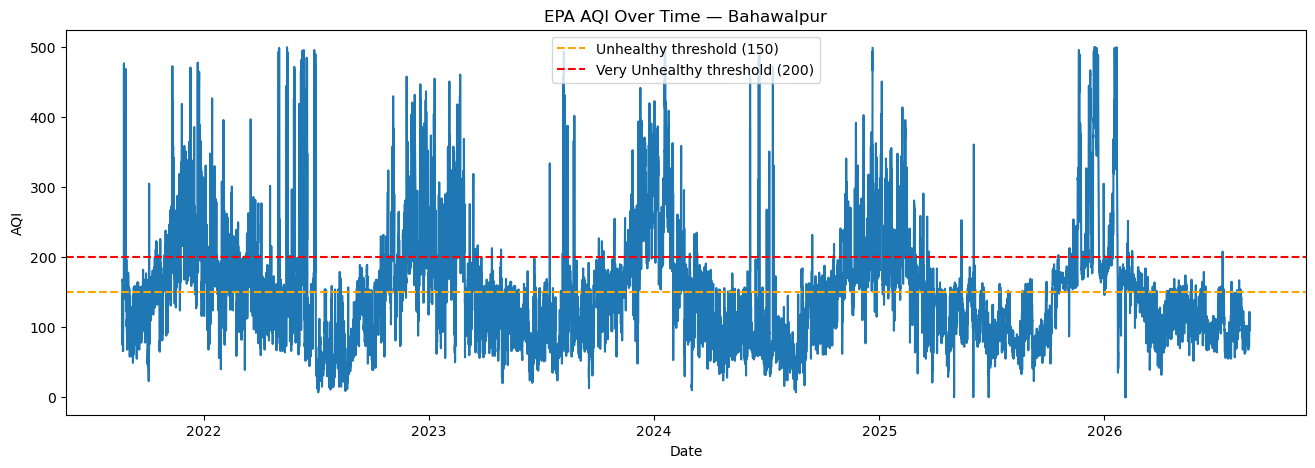

In [5]:
plt.figure(figsize=(16, 5))
plt.plot(df["datetime"], df["aqi_epa"])
plt.axhline(150, color="orange", linestyle="--", label="Unhealthy threshold (150)")
plt.axhline(200, color="red", linestyle="--", label="Very Unhealthy threshold (200)")
plt.title("EPA AQI Over Time — Bahawalpur")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.show()

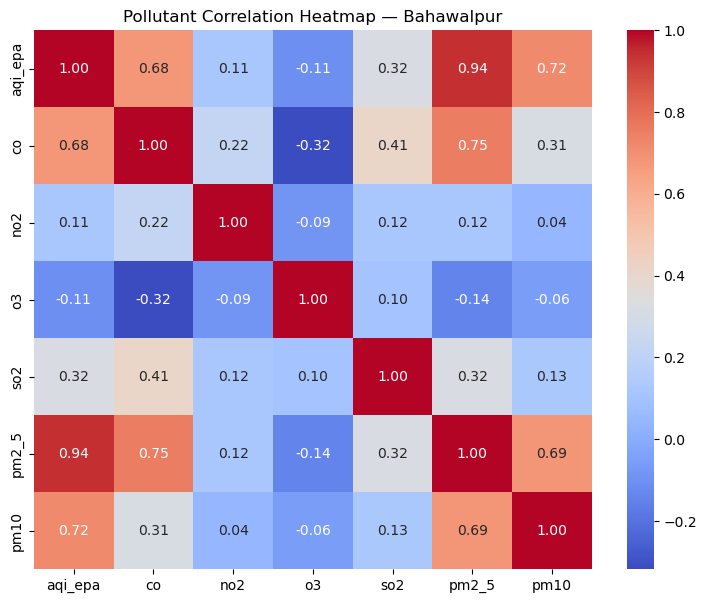

In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[["aqi_epa", "co", "no2", "o3", "so2", "pm2_5", "pm10"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pollutant Correlation Heatmap — Bahawalpur")
plt.show()

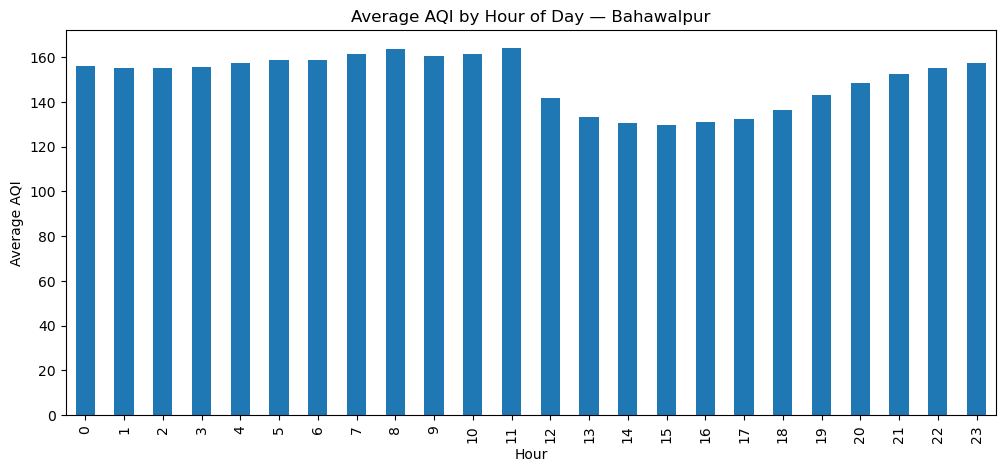

In [7]:
df["hour"] = df["datetime"].dt.hour
hourly_avg = df.groupby("hour")["aqi_epa"].mean()

plt.figure(figsize=(12, 5))
hourly_avg.plot(kind="bar")
plt.title("Average AQI by Hour of Day — Bahawalpur")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.show()

## Lahore

In [8]:
df = data["lahore"]
df.head()

,datetime,aqi_epa,openweather_aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2021-09-05 16:00:00,173.0,5.0,761.03,0.39,8.05,181.68,12.16,98.45,103.44,6.90
1,2021-09-05 17:00:00,173.0,5.0,787.74,0.26,9.77,170.23,10.73,98.20,103.44,7.92
2,2021-09-05 18:00:00,178.0,5.0,1188.28,0.19,33.93,105.86,7.75,107.71,116.75,13.68
3,2021-09-05 19:00:00,188.0,5.0,1682.28,0.10,56.89,35.76,8.23,127.36,142.99,22.04
4,2021-09-05 20:00:00,202.0,5.0,2216.34,4.86,68.55,3.62,10.13,151.97,173.49,28.37


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42816 entries, 0 to 42815
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         42816 non-null  datetime64[ns]
 1   aqi_epa          40125 non-null  float64       
 2   openweather_aqi  42816 non-null  float64       
 3   co               42816 non-null  float64       
 4   no               42816 non-null  float64       
 5   no2              42816 non-null  float64       
 6   o3               42816 non-null  float64       
 7   so2              42816 non-null  float64       
 8   pm2_5            42816 non-null  float64       
 9   pm10             42816 non-null  float64       
 10  nh3              42816 non-null  float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 3.6 MB


,datetime,aqi_epa,openweather_aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,42816,40125.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000
mean,2024-02-29 21:26:50.313901056,197.023551,4.431225,2286.911482,19.791570,43.046033,69.563087,15.322309,171.745298,214.449763,23.653568
min,2021-09-05 16:00:00,0.000000,1.000000,111.060000,0.000000,-9999.000000,-9999.000000,0.460000,0.000000,-9999.000000,0.000000
25%,2022-11-29 15:45:00,129.000000,4.000000,640.870000,0.030000,10.540000,4.920000,5.190000,48.950000,74.095000,8.040000
50%,2024-02-28 15:30:00,168.000000,5.000000,1255.040000,0.770000,24.680000,48.640000,10.490000,97.110000,130.960000,15.870000
75%,2025-06-01 15:15:00,239.000000,5.000000,2937.320000,12.290000,58.950000,111.580000,20.030000,225.035000,283.640000,30.650000
max,2026-09-04 15:00:00,500.000000,5.000000,25421.140000,686.650000,658.040000,698.090000,165.940000,1641.500000,1890.510000,389.100000
std,NaN,102.888345,0.856043,2598.146211,47.867051,84.701443,88.427773,15.384902,186.544863,217.330760,25.057084


In [10]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate timestamps:", df["datetime"].duplicated().sum())

Missing values:
datetime              0
aqi_epa            2691
openweather_aqi       0
co                    0
no                    0
no2                   0
o3                    0
so2                   0
pm2_5                 0
pm10                  0
nh3                   0
dtype: int64

Duplicate timestamps: 0


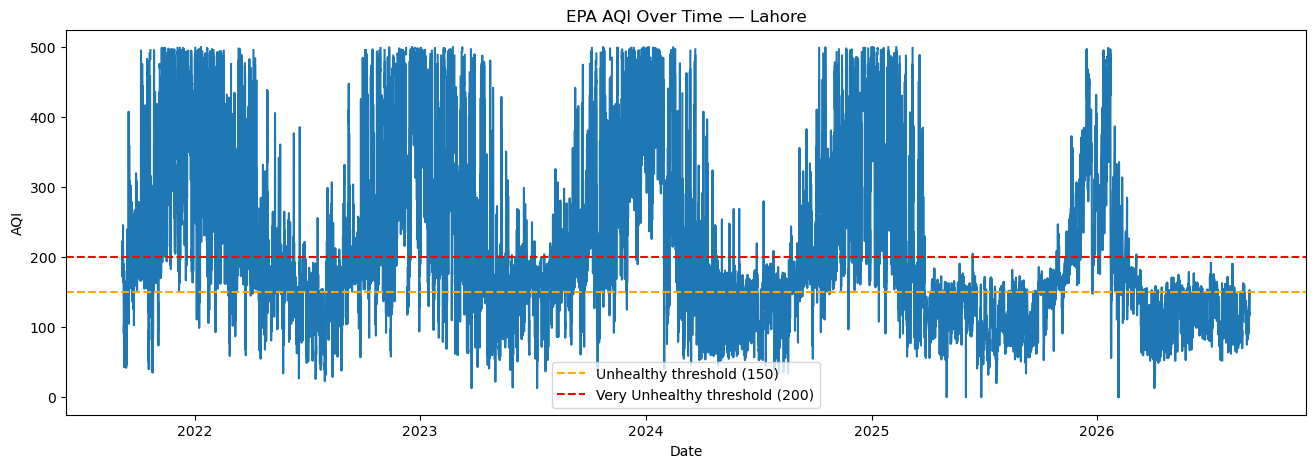

In [11]:
plt.figure(figsize=(16, 5))
plt.plot(df["datetime"], df["aqi_epa"])
plt.axhline(150, color="orange", linestyle="--", label="Unhealthy threshold (150)")
plt.axhline(200, color="red", linestyle="--", label="Very Unhealthy threshold (200)")
plt.title("EPA AQI Over Time — Lahore")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.show()

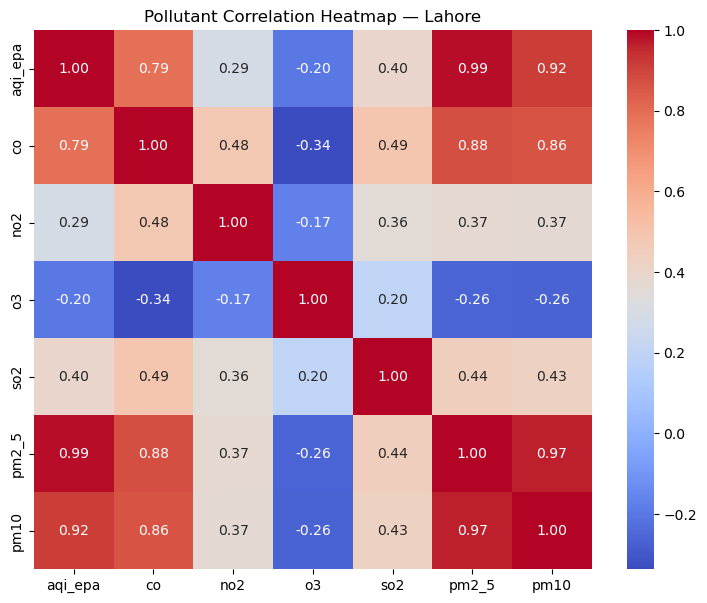

In [12]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[["aqi_epa", "co", "no2", "o3", "so2", "pm2_5", "pm10"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pollutant Correlation Heatmap — Lahore")
plt.show()

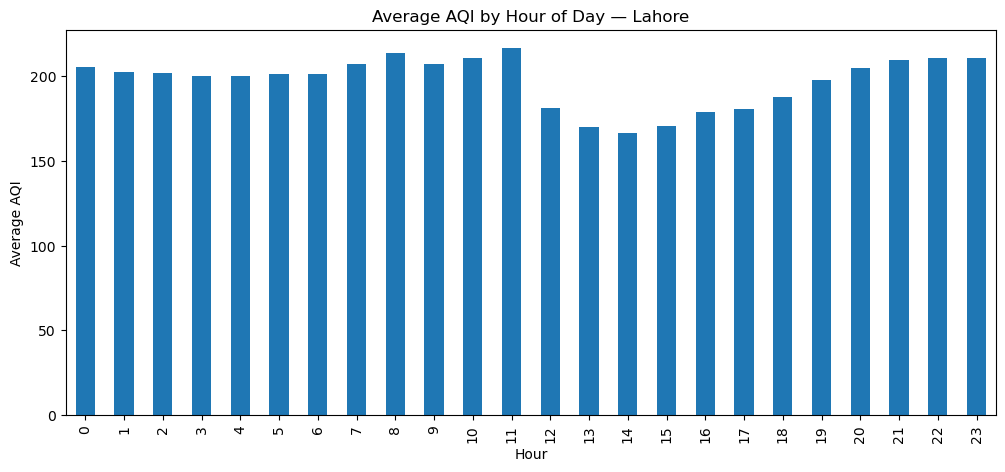

In [13]:
df["hour"] = df["datetime"].dt.hour
hourly_avg = df.groupby("hour")["aqi_epa"].mean()

plt.figure(figsize=(12, 5))
hourly_avg.plot(kind="bar")
plt.title("Average AQI by Hour of Day — Lahore")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.show()

## Islamabad

In [14]:
df = data["islamabad"]
df.head()

,datetime,aqi_epa,openweather_aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2021-09-05 16:00:00,164.0,5,821.11,0.61,11.82,197.41,27.66,80.92,90.00,11.53
1,2021-09-05 17:00:00,165.0,5,934.60,0.52,18.34,197.41,35.29,82.03,91.19,11.78
2,2021-09-05 18:00:00,174.0,5,3017.43,2.07,127.49,80.11,36.72,99.48,111.75,20.77
3,2021-09-05 19:00:00,189.0,5,5821.23,17.21,216.60,1.48,32.42,129.71,146.97,30.91
4,2021-09-05 20:00:00,212.0,5,7370.00,37.55,227.57,0.00,29.09,161.21,182.66,36.99


In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42816 entries, 0 to 42815
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         42816 non-null  datetime64[ns]
 1   aqi_epa          42443 non-null  float64       
 2   openweather_aqi  42816 non-null  int64         
 3   co               42816 non-null  float64       
 4   no               42816 non-null  float64       
 5   no2              42816 non-null  float64       
 6   o3               42816 non-null  float64       
 7   so2              42816 non-null  float64       
 8   pm2_5            42816 non-null  float64       
 9   pm10             42816 non-null  float64       
 10  nh3              42816 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 3.6 MB


,datetime,aqi_epa,openweather_aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,42816,42443.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000,42816.000000
mean,2024-03-01 08:07:44.125560576,170.392809,4.247688,2499.648130,31.358296,58.636304,65.226237,13.399747,110.651872,139.021074,32.806261
min,2021-09-05 16:00:00,0.000000,1.000000,127.580000,0.000000,-9999.000000,-9999.000000,0.370000,0.000000,-9999.000000,0.000000
25%,2022-11-29 15:45:00,110.000000,4.000000,654.927500,0.080000,12.170000,1.100000,4.530000,39.590000,54.010000,8.490000
50%,2024-02-28 15:30:00,159.000000,5.000000,1375.200000,1.510000,35.300000,54.360000,9.660000,71.090000,97.875000,19.760000
75%,2025-06-02 15:15:00,194.000000,5.000000,3417.970000,32.190000,91.850000,110.832500,17.400000,140.772500,180.592500,44.080000
max,2026-09-04 15:00:00,500.000000,6.000000,21568.000000,578.000000,482.560000,452.040000,164.030000,1091.810000,1204.590000,385.050000
std,NaN,88.292966,0.950562,2702.411108,62.698811,91.609559,80.845544,13.120006,108.780393,134.321964,36.604364


In [16]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate timestamps:", df["datetime"].duplicated().sum())

Missing values:
datetime             0
aqi_epa            373
openweather_aqi      0
co                   0
no                   0
no2                  0
o3                   0
so2                  0
pm2_5                0
pm10                 0
nh3                  0
dtype: int64

Duplicate timestamps: 0


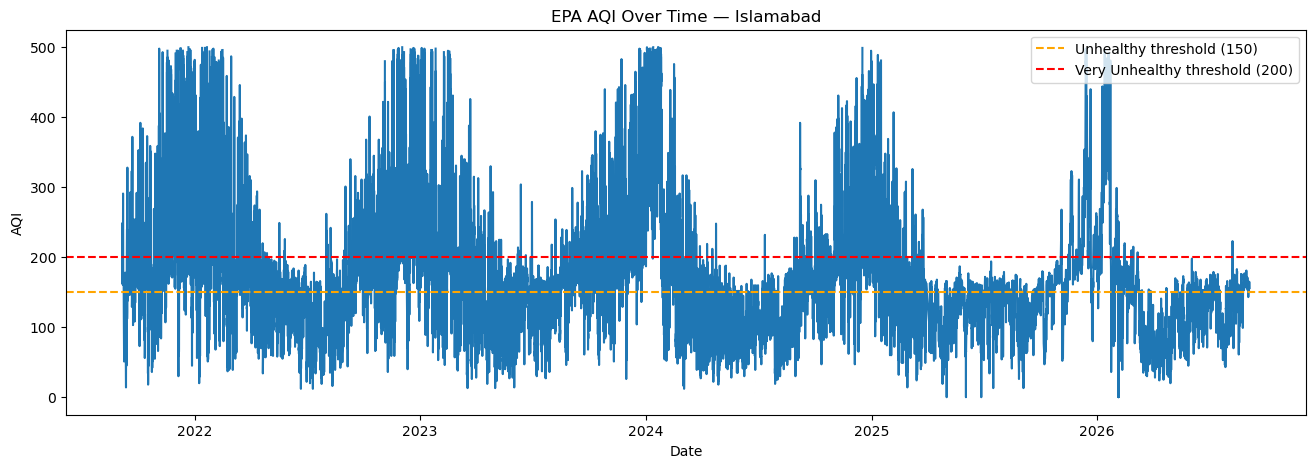

In [17]:
plt.figure(figsize=(16, 5))
plt.plot(df["datetime"], df["aqi_epa"])
plt.axhline(150, color="orange", linestyle="--", label="Unhealthy threshold (150)")
plt.axhline(200, color="red", linestyle="--", label="Very Unhealthy threshold (200)")
plt.title("EPA AQI Over Time — Islamabad")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.show()

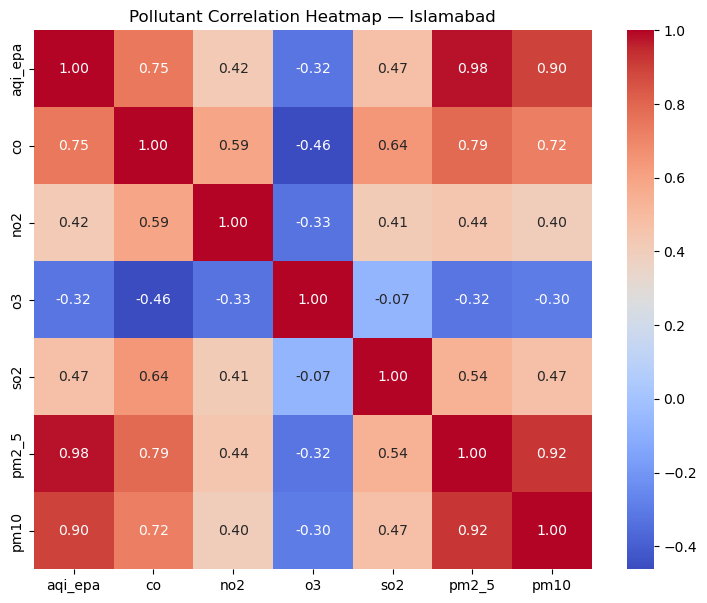

In [18]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[["aqi_epa", "co", "no2", "o3", "so2", "pm2_5", "pm10"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pollutant Correlation Heatmap — Islamabad")
plt.show()

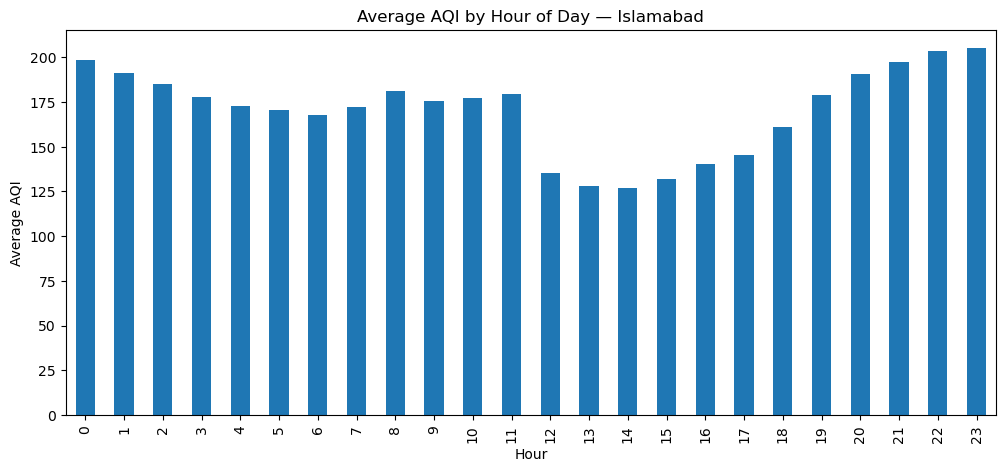

In [19]:
df["hour"] = df["datetime"].dt.hour
hourly_avg = df.groupby("hour")["aqi_epa"].mean()

plt.figure(figsize=(12, 5))
hourly_avg.plot(kind="bar")
plt.title("Average AQI by Hour of Day — Islamabad")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.show()

## Cross-City Comparison

Overlaying all three cities on the same axes to compare pollution levels
and daily rhythms directly, rather than looking at each city in isolation.

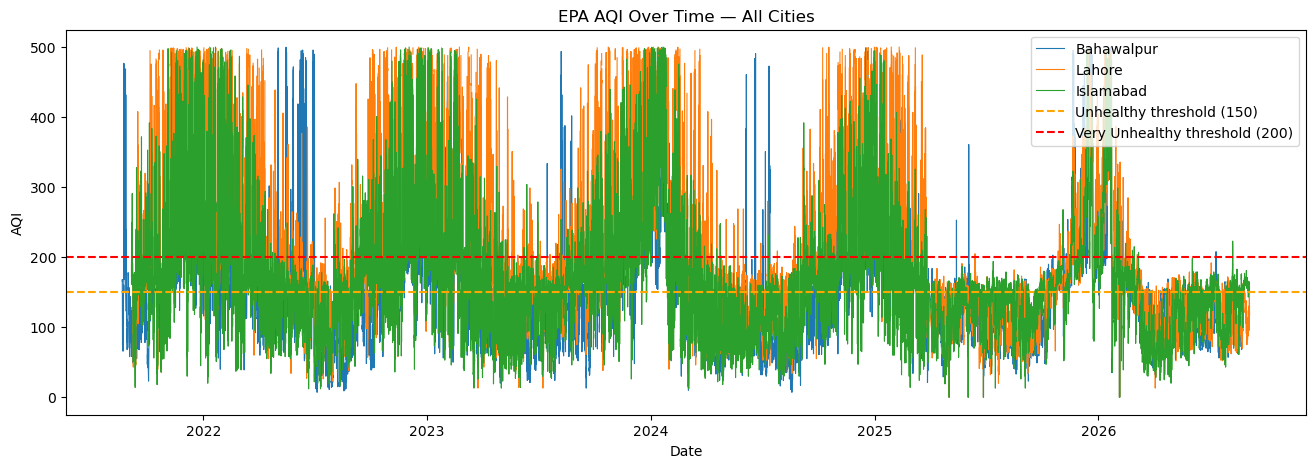

In [20]:
plt.figure(figsize=(16, 5))
for city, df in data.items():
    plt.plot(df["datetime"], df["aqi_epa"], label=city.title(), linewidth=0.8)
plt.axhline(150, color="orange", linestyle="--", label="Unhealthy threshold (150)")
plt.axhline(200, color="red", linestyle="--", label="Very Unhealthy threshold (200)")
plt.title("EPA AQI Over Time — All Cities")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.show()

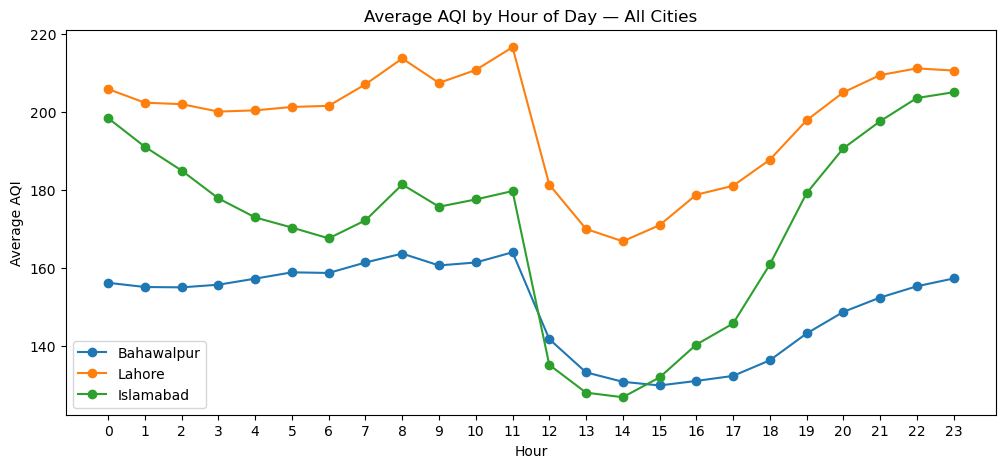

In [21]:
plt.figure(figsize=(12, 5))
for city, df in data.items():
    hourly_avg = df.assign(hour=df["datetime"].dt.hour).groupby("hour")["aqi_epa"].mean()
    plt.plot(hourly_avg.index, hourly_avg.values, marker="o", label=city.title())
plt.title("Average AQI by Hour of Day — All Cities")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.legend()
plt.show()

In [22]:
summary = pd.DataFrame({
    city: {
        "mean_aqi": df["aqi_epa"].mean(),
        "median_aqi": df["aqi_epa"].median(),
        "max_aqi": df["aqi_epa"].max(),
        "pct_unhealthy_or_worse": (df["aqi_epa"] > 150).mean() * 100,
    }
    for city, df in data.items()
}).T.round(1)
summary

,mean_aqi,median_aqi,max_aqi,pct_unhealthy_or_worse
bahawalpur,149.9,148.0,500.0,49.2
lahore,197.0,168.0,500.0,64.0
islamabad,170.4,159.0,500.0,60.1
